# IML 2026 — Machine Learning Laboratory
## LAB 02: Exploratory Data Analysis and K-Nearest Neighbors

**Topic:** K-Nearest Neighbors (KNN) Classification  
**Submission:** `IML2026_Roll-No_Lab_02.ipynb`

### Learning Objectives
- Load and inspect a real dataset.
- Perform basic exploratory data analysis.
- Separate features and target.
- Prepare data using standard train/test splitting and feature scaling.
- Understand KNN.
- Implement the **KNN algorithm from scratch**.
- Evaluate the implementation using accuracy and a confusion matrix.
- Study the effect of different values of K.

### Implementation Rule
You may use standard utilities for **train/test splitting, feature standardization, accuracy, confusion matrix, data handling, and visualization**.

You must implement the **KNN logic yourself**: distance calculation, neighbor selection, majority voting, and prediction.

**Do not use a ready-made KNN classifier such as `KNeighborsClassifier`.**

## Dataset — Iris

Download the Iris dataset from the UCI Machine Learning Repository:

**https://archive.ics.uci.edu/dataset/53/iris**

Download the dataset and upload the required data file to your Colab session.

**Do not use `sklearn.datasets.load_iris()`**.

The Iris dataset contains 150 observations, four input features, and three target classes.

# Part A — Import Required Libraries

You may use NumPy, Pandas, Matplotlib and the following Scikit-learn utilities:
- `train_test_split`
- `StandardScaler`
- `accuracy_score`
- `confusion_matrix`

No ready-made KNN classifier is allowed.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

# Part B — Load the Dataset

Load the Iris dataset you downloaded from the UCI repository using Pandas.

**Student task:** write the loading code yourself.

Do not use `sklearn.datasets.load_iris()`.

In [8]:
# Load
df = pd.read_csv(os.getcwd() + "/iris/iris.data", header=None)

# Assigning the names from iris.names file manually
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

df.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


# Part C — Dataset Inspection

Perform:
```python
df.head()
df.tail()
df.shape
df.columns
df.info()
df.describe()
```

Also determine the number of samples in each target class.

**Q1.** How many rows and columns are present?

**Q2.** What are the input features?

**Q3.** Which column represents the target?

**Q4.** How many target classes are present?

**Q5.** How many observations belong to each class?

In [17]:
# print("First 5 datapoints\n", df.head(), "\n")
# print("Last 5 datapoints\n", df.tail(), "\n")
# print("#rows, #cols: ", df.shape, "\n")
# print("The columns are ", df.columns, "\n")
# print(df.info())
# print("\n")
# print(df.describe())
# print("\n")
# print("\n")

print("Q1.")
print("Number of rows and columns: ", df.shape[0], df.shape[1])
print("\n")

print("Q2.")
print("Input features: ", df.drop(columns=['class']).columns)
print("\n")

print("Q3.")
print("Target: ", 'class')
print("\n")

print("Q4.")
unique_class = df['class'].nunique()   
print("number of classes: ", unique_class)
print("\n")

print("Q1.")
counts = df['class'].value_counts()   
print("each contain:\n", counts)


Q1.
Number of rows and columns:  150 5


Q2.
Input features:  Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='str')


Q3.
Target:  class


Q4.
number of classes:  3


Q1.
each contain:
 class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


# Part D — Missing-Value Analysis

Check every column for missing values.

**Q6.** Does the dataset contain missing values?

**Q7.** Why should missing values be checked before applying a Machine Learning algorithm?

In [33]:
print("Q6.\n")
# Count missing values in each column
print(df.isnull().sum())
print("There is no missing values in this dataset.")

print("\nQ7.\n")
print("If missing values are not checked, algorithms may break altogether in the worst case. Or it may train falsely.")



Q6.

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
class           0
dtype: int64
There is no missing values in this dataset.

Q7.

If missing values are not checked, algorithms may break altogether in the worst case. Or it may train falsely.


# Part E — Exploratory Data Analysis

Create:

**Q8.** Histograms for the four numerical features.

**Q9.** A scatter plot of Petal Length vs Petal Width.

**Q10.** A bar chart showing the class distribution.

Write 1–2 observations for each visualization.

Q8. Hist plots.


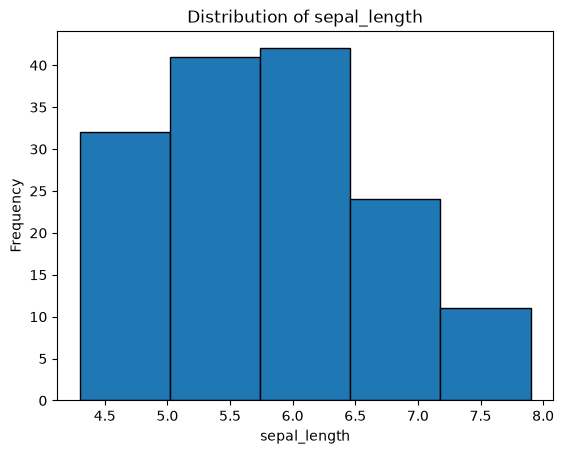

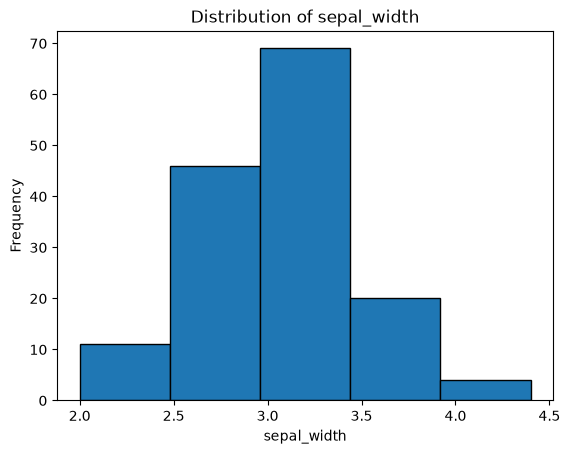

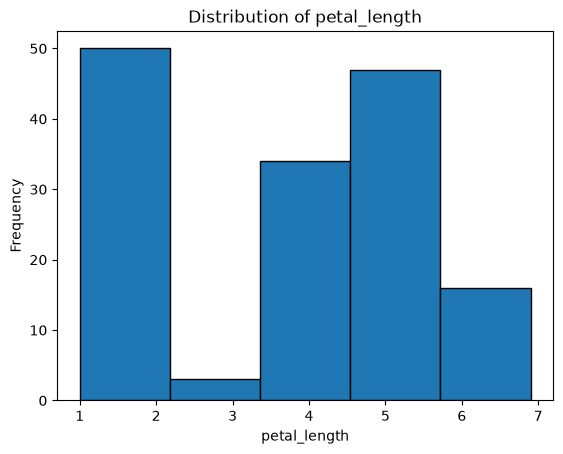

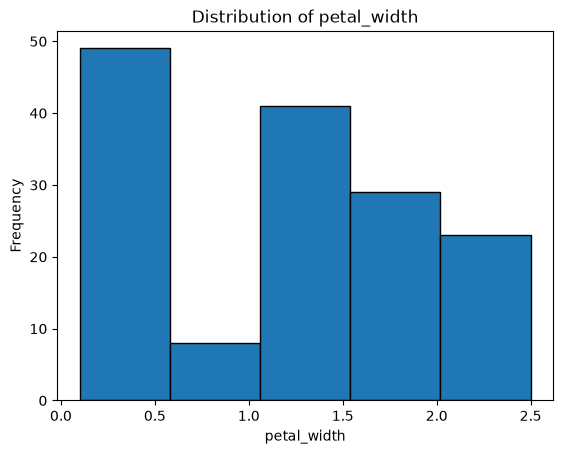



Q9. scatter plot.


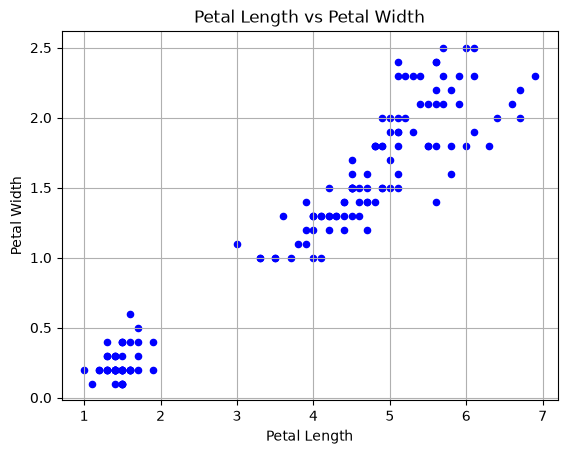



Q10. bar plot.


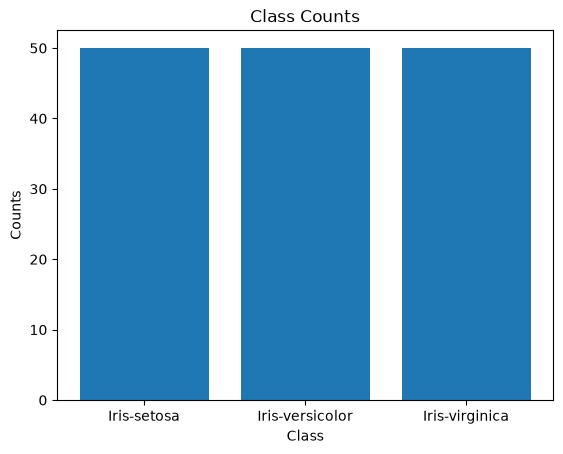


Observations




In [ ]:
print("Q8. Hist plots.")
for i in range(4):
    plt.hist(df.iloc[:, i], bins=5, edgecolor="black")
    plt.xlabel(f"{df.columns[i]}")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {df.columns[i]}")
    plt.show()

print("\n")
print("Q9. scatter plot.")
plt.scatter(df['petal_length'], df['petal_width'], s=20, color='blue')
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Petal Length vs Petal Width")
plt.grid(True)
plt.show()

print("\n")
print("Q10. bar plot.")
plt.bar(counts.index, counts.values)
plt.xlabel("Class")
plt.ylabel("Counts")
plt.title("Class Counts")
plt.show()


print("\nObservations\n")
print("Sepal distributions follow a normal bell curve, while petal distribution is low for the 2nd group.")
print("Positive corelation between petal length and width.")
print("All three classes have equal number of datapoints.")

# Part F — Separate Features and Target

Create:
```python
X = ...
y = ...
```

`X` contains the input features and `y` contains the target labels.

Verify their shapes and display the first five values.

In [24]:
# Separate features (X) and target (y)
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['class']   

print(X.shape)
print(y.shape)

print(X.head())
print(y.head())

(150, 4)
(150,)
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: class, dtype: str


# Part G — Train/Test Split

You **may use `train_test_split()`**.

Requirements:
- 80% training data
- 20% testing data
- `random_state=42`
- `stratify=y`

Example:
```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
```

**Q11.** Why is it important to evaluate the model on data that was not used during training?

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Q11. We evaluate model data on unseen data because eventually we want to deploy the model for unknown cases, if we test on only training data, model may overfit and perform poor on new data.")

Q11. We evaluate model data on unseen data because eventually we want to deploy the model for unknown cases, if we test on only training data, model may overfit and perform poor on new data.


# Part H — Feature Standardization

You **may use `StandardScaler`**.

```python
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
```

Use `fit_transform()` only on training data and `transform()` on testing data.

**Q12.** Why is feature scaling important for a distance-based algorithm such as KNN?

In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Q12. Distnace has units and different units/ order of magnitude will give more importance to a feature than the other.")

Q12. Distnace has units and different units/ order of magnitude will give more importance to a feature than the other.


# Part I — Understanding KNN

For a new test sample:

1. Calculate its distance from every training sample.
2. Sort the samples by distance.
3. Select the nearest K samples.
4. Examine their class labels.
5. Perform majority voting.
6. Assign the majority class.

### Euclidean Distance
For two points x and y:

`d(x,y) = sqrt(sum((xi - yi)^2))`

You must implement this calculation yourself.

# Part J — Implement Euclidean Distance

**Q13.** Implement:
```python
euclidean_distance(point1, point2)
```

Do not use a ready-made KNN or distance function.

In [ ]:
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))

# Part K — Implement KNN for One Test Sample

**Q14.** Implement:
```python
knn_predict_single(X_train, y_train, test_point, k)
```

The function must:
1. Calculate distance to every training sample.
2. Store distances with their labels.
3. Sort by distance.
4. Select the nearest `k` samples.
5. Count their class labels.
6. Return the majority class.

**Do not use `KNeighborsClassifier` or any ready-made KNN implementation.**

In [29]:
from collections import Counter

def knn_predict_single(X_train, y_train, test_point, k):
    distances = []
    for i in range(len(X_train)):
        dist = euclidean_distance(X_train[i], test_point)
        distances.append((dist, y_train[i]))
    
    distances.sort(key=lambda x: x[0])
    k_nearest = distances[:k]
    k_labels = [label for (_, label) in k_nearest]
    majority_vote = Counter(k_labels).most_common(1)[0][0]

    return majority_vote   


# Part L — Test a Single Prediction

Use `K = 3` and predict one test sample.

**Q15.** Display the actual class, predicted class, and whether the prediction is correct.

In [32]:
K = 3

single_test_point = X_test_scaled[0]
actual_class = y_test.iloc[0]

predicted_class = knn_predict_single(X_train_scaled, y_train.values, single_test_point, K)

print(f"Actual Class: {actual_class}")
print(f"Predicted Class: {predicted_class}")
print(f"Correct Prediction: {actual_class == predicted_class}")   

Actual Class: Iris-setosa
Predicted Class: Iris-setosa
Correct Prediction: True


# Part M — Implement KNN for the Complete Test Set

Create:
```python
knn_predict(X_train, y_train, X_test, k)
```

Use your own KNN implementation to predict every test sample.

Do not call a ready-made KNN classifier.

In [ ]:
def knn_predict(X_train, y_train, X_test, k):
    predictions = []
    for i in range(len(X_test)):
        pred = knn_predict_single(X_train, y_train, X_test[i], k)
        predictions.append(pred)
    return predictions


# Part N — Evaluate the KNN Implementation

For evaluation, you **may use Scikit-learn utilities**:
- `accuracy_score()`
- `confusion_matrix()`

**Q16.** Run your KNN implementation with `K = 5` and report the accuracy and confusion matrix.

**Q17.** Explain what the rows and columns of the confusion matrix represent.

In [38]:
K = 5

y_pred = knn_predict(X_train_scaled, y_train.values, X_test_scaled, K)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy (K={K}): {accuracy:.4f}")
print("Confusion Matrix:")
print(cm)

print("Rows in confusion matrix represent the actual (true) Classes. Each row corresponds to the true label of the samples. Columns represent the Predicted Classes. Each column corresponds to the class label predicted by the model.")


Accuracy (K=5): 0.9333
Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]
Rows in confusion matrix represent the actual (true) Classes. Each row corresponds to the true label of the samples. Columns represent the Predicted Classes. Each column corresponds to the class label predicted by the model.


# Part O — Experiment With Different Values of K

Evaluate your **own KNN implementation** for:

`K = 1, 3, 5, 7, 9`

For every K:
1. Generate predictions.
2. Calculate accuracy using `accuracy_score()`.
3. Store the result.

Create a results table.

**Q18.** Which value of K produced the highest accuracy?

In [ ]:
k_values = [1, 3, 5, 7, 9]
results = []

y_train_arr = y_train.values 

for k in k_values:
    y_pred = knn_predict(X_train_scaled, y_train_arr, X_test_scaled, k)
    
    acc = accuracy_score(y_test, y_pred)
    results.append({'K': k, 'Accuracy': acc})


results_df = pd.DataFrame(results)
print("\nResults Table:")
print(results_df)

# Identify best K
best_row = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"\nHighest Accuracy: {best_row['Accuracy']:.4f} at K = {int(best_row['K'])}")   


Results Table:
   K  Accuracy
0  1  0.966667
1  3  0.933333
2  5  0.933333
3  7  0.966667
4  9  0.966667

Highest Accuracy: 0.9667 at K = 1


# Part P — Visualize K vs Accuracy

Create a line plot:
- X-axis → K
- Y-axis → Accuracy

**Q19.** What trend do you observe as K changes? Explain your observation.

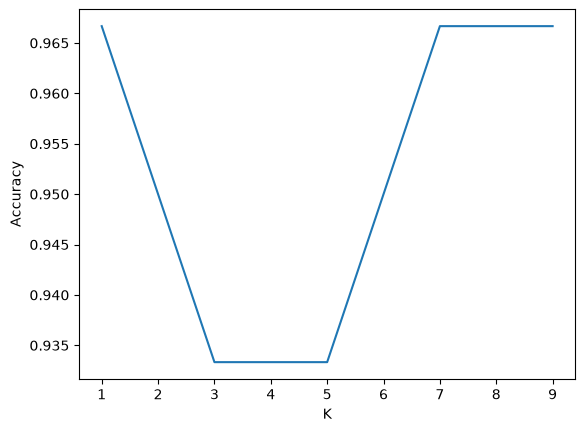

We see a dip at 3 and 5 and higher values otherwise.


In [42]:
plt.plot(results_df['K'], results_df['Accuracy'])
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

print("We see a dip at 3 and 5 and higher values otherwise.")

# Part Q — Final Model Evaluation

Select the best K from your experiment.

Report:
1. Best K
2. Test accuracy
3. Confusion matrix
4. Number of correct predictions
5. Number of incorrect predictions

Use library functions only for evaluation metrics.

In [43]:
best_k = 1

y_train_arr = y_train.values
y_pred = knn_predict(X_train_scaled, y_train_arr, X_test_scaled, best_k)

accuracy = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

correct_predictions = np.trace(cm)
incorrect_predictions = len(y_test) - correct_predictions

print(f"1. Best K: {best_k}")
print(f"2. Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"3. Confusion Matrix:\n{cm}")
print(f"4. Number of Correct Predictions: {correct_predictions}")
print(f"5. Number of Incorrect Predictions: {incorrect_predictions}")

1. Best K: 1
2. Test Accuracy: 0.9667 (96.67%)
3. Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]
4. Number of Correct Predictions: 29
5. Number of Incorrect Predictions: 1


# Part R — Conceptual Questions

**Q20.** Why does KNN use distance to classify a new sample?

**Q21.** Why is feature scaling important for KNN?

**Q22.** What is the effect of choosing a very small K?

**Q23.** What is the effect of choosing a very large K?

**Q24.** Explain the complete KNN prediction process in your own words.

**Q25.** Why is KNN commonly described as a lazy learning algorithm?

**Q26.** Compare K = 1, 3, 5, 7 and 9. What did you observe?

In [44]:
# Part R — Conceptual Questions

print("Q20. KNN's fundamental assumption is that similar data points exist close to each other in the feature space. By calculating the distance (e.g., Euclidean) between a new sample and all training points, the algorithm identifies the closest neighbors. It assumes that the new sample likely belongs to the same class as the majority of these closest points.")

print("Q21. KNN relies on distance calculations, which are sensitive to the units and order of magnitude of the features. If one feature has a large range and another has a small range, the feature with the larger range will dominate the distance calculation. Feature scaling (like Standardization) ensures all features contribute equally to the distance metric, preventing bias toward features with larger scales.")

print("Q22. Choosing a very small K makes the model highly sensitive to noise and outliers. The decision boundary becomes very complex, fitting the training data too closely. This leads to high variance and overfitting, where the model performs well on training data but poorly on unseen test data.")

print("Q23. Choosing a very large K smooths the decision boundary excessively. The model considers too many neighbors, potentially including points from distant classes. This leads to high bias and underfitting, where the model becomes too simple and fails to capture local structures or nuances in the data.")

print("Q24. Keep the entire training dataset in memory For a new test point, compute the distance to every single point in the training set. Sort these distances in ascending order and pick the top $K$ closest points (neighbors). Look at the class labels of these $K$ neighbors. Assign the class label that appears most frequently among the neighbors (mode) to the new test point.")

print("Q25. KNN is called lazy learning because it performs no generalization or model training during the training phase. It simply memorizes the entire dataset.")

print("Q26. K=1 achieved best result, but that is not reliable. it is probably overfitted. K=3 and 5 It provides balance at the cost of some accuracy, but not hugely. K=7 and 9 provides probably the best result, better accuracy (close to K=1), without overfitting.")



Q20. KNN's fundamental assumption is that similar data points exist close to each other in the feature space. By calculating the distance (e.g., Euclidean) between a new sample and all training points, the algorithm identifies the closest neighbors. It assumes that the new sample likely belongs to the same class as the majority of these closest points.
Q21. KNN relies on distance calculations, which are sensitive to the units and order of magnitude of the features. If one feature has a large range and another has a small range, the feature with the larger range will dominate the distance calculation. Feature scaling (like Standardization) ensures all features contribute equally to the distance metric, preventing bias toward features with larger scales.
Q22. Choosing a very small K makes the model highly sensitive to noise and outliers. The decision boundary becomes very complex, fitting the training data too closely. This leads to high variance and overfitting, where the model performs

# Submission Requirements

Before submitting, verify that your notebook contains:

- [ ] Iris dataset downloaded from UCI
- [ ] Dataset loaded using Pandas
- [ ] Dataset inspection
- [ ] Missing-value analysis
- [ ] Required visualizations
- [ ] Feature/target separation
- [ ] Train/test split using `train_test_split`
- [ ] Feature standardization using `StandardScaler`
- [ ] Euclidean distance implemented by you
- [ ] KNN prediction implemented by you
- [ ] Complete test-set prediction implemented by you
- [ ] Accuracy calculated using `accuracy_score`
- [ ] Confusion matrix calculated using `confusion_matrix`
- [ ] Experiments for K = 1, 3, 5, 7, 9
- [ ] K vs accuracy plot
- [ ] Final evaluation
- [ ] Q1–Q26 answered

## Allowed
NumPy, Pandas, Matplotlib, `train_test_split`, `StandardScaler`, `accuracy_score`, `confusion_matrix`.

## Not Allowed
`KNeighborsClassifier` or any other ready-made KNN implementation.

### Submission File Name
```text
IML2026_Roll-No_Lab_02.ipynb
```

Upload the completed notebook to Google Classroom before the deadline.